# Modelagem Preditiva da Viralização

Este notebook documenta a construção e avaliação de modelos de Machine Learning usados para prever o sucesso de vídeos.

O foco é identificar sinais precocesde alta perfomance, evitando o uso de métricas acumuladas (Data Leakage).

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("../data/external/youtube_shorts_tiktok_trends_2025.csv")

### 1. Definição do Target (Rótulo de Sucesso)

Diferentemente do usado na análise explorátoria, aqui redefinimos "viral" como o Top 25% de performance em visualizações.

Essa mudança permite transformar o problema que antes era de detecção de anomalias raras em um classificador de vídeos virais, além de ajudar no treinamento dos modelos, já que a  classe viral possuirá mais dados.

In [3]:
threshold_viral = df["views"].quantile(0.75)
df['is_viral'] = (df['views'] > threshold_viral).astype(int)

### 2. Pré-processamento e Enconding

Transformamos variáveis  categóricas e temporais em formatos numéricos para que os modelos consigam interpretar, com atenção especial à natureza cíclica do tempo.

Enconding binário para plataforma

In [4]:
df['platform_encoded'] = df['platform'].map({'TikTok': 0, 'YouTube': 1})

Ordinal Enconding para o Tier do criador

In [5]:
df['creator_tier_encoded'] = df['creator_tier'].map({'Micro': 0, 'Mid': 1, 'Macro': 2, 'Star': 3})

Conversão de booleano para int

In [6]:
df['has_emoji_encoded'] = df['has_emoji'].astype(int)

Transformação cíclida da hora de upload, isso impede que o modelo trate 23h e 00h como extremos opostos, unindo-os em um círculo trigonométrico.

In [7]:
df['hour_sin'] = np.sin(2 * np.pi * df['upload_hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['upload_hour'] / 24)

### 3. Seleção de Atributos (Feature Selection)

Selecionamos apenas variáveis conhecidas no momento da  postagem ou sinais de eficiência inicial.

Métricas absolutas, como views, likes totais, e semelhantes não foram selecionadas para evitar Data Leakage, já que representam informações do vídeo já consolidado nas plataformas, e como nosso problema é prever viralização, essas features não podem ser usadas.

In [8]:
# features = [
#     'platform_encoded',
#     'has_emoji_encoded',
#     'duration_sec',
#     'completion_rate',
#     'engagement_velocity',
#     'creator_avg_views'
# ]

# features = [
#     'platform_encoded',
#     'duration_sec',
#     'completion_rate',
#     # 'engagement_velocity',
#     'creator_avg_views',
#     'creator_tier_encoded',
#     'like_rate',
#     'is_weekend',
#     'upload_hour',
#     # 'traffic_source'
# ]

features = [
    'platform_encoded',
    'duration_sec',
    'creator_avg_views',
    'completion_rate',
    'title_length',
    'has_emoji_encoded',
    'is_weekend',
    'hour_sin',
    'hour_cos',
    'creator_tier_encoded',
    'like_rate',
    'share_rate',
    'completion_rate',
    'engagement_per_1k'
]

X = df[features]
y = df['is_viral']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f" Amostras de Treino: {len(X_train)} | Amostras de Teste: {len(X_test)}")
print(f"Taxa de Viralização: {y_train.mean():.2}")

 Amostras de Treino: 38463 | Amostras de Teste: 9616
Taxa de Viralização: 0.25


### 4. Escalonamento de Variáveis e Modelos

Modelos lineares, como a regressão logística, são sensíveis à escala. Padronizamos os dados para que variáveis com números grandes não dominem variáveis de escala menor.

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Baseline: Regressão Logística

Utilizamos a Regressão Logística como primeiro experimento. Por ser um modelo linear, ela nos ajuda a entender se existe uma separação clara e simples entre as classes.

Usamos 'class_weight=balanced' para compensar o desbalanceamento de 75/25.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

model_lr = LogisticRegression(random_state=42, class_weight='balanced')
model_lr.fit(X_train_scaled, y_train)

y_pred_lr = model_lr.predict(X_test_scaled)
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))
print("Logistic Regression ROC AUC:", roc_auc_score(y_test, model_lr.predict_proba(X_test_scaled)[:, 1]))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.58      0.66      7212
           1       0.28      0.50      0.36      2404

    accuracy                           0.56      9616
   macro avg       0.53      0.54      0.51      9616
weighted avg       0.65      0.56      0.59      9616

Logistic Regression ROC AUC: 0.5547238587379326


#### Random Forest

O Random Forest é capaz de capturar relações não-lineares.

O uso de 'balanced_subsample' é vital para que o modelo aprende as características da classse viral, que ainda é minoria.

In [11]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced_subsample')
model_rf.fit(X_train_scaled, y_train)

y_pred_rf = model_rf.predict(X_test_scaled)
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))
print("Random Forest ROC AUC:", roc_auc_score(y_test, model_rf.predict_proba(X_test_scaled)[:, 1]))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.62      0.69      7212
           1       0.28      0.44      0.34      2404

    accuracy                           0.58      9616
   macro avg       0.53      0.53      0.52      9616
weighted avg       0.65      0.58      0.60      9616

Random Forest ROC AUC: 0.5463598638062095


#### XGBoost

Como tentativa final, utilizamos o XGBoost para verificar se o ganho de erro iterativo (boosting) tratia uma performance superior. Ajustamos o limiar para 0.3 para tentar equilibrar a sensibilidade do modelo.

In [ ]:
from xgboost import XGBClassifier

X_train_num = pd.get_dummies(X_train, drop_first=True)
X_test_num = pd.get_dummies(X_test, drop_first=True)

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.05,
    scale_pos_weight=pos_weight,
    eval_metric='logloss',
    random_state=42
)

model_xgb.fit(X_train_num.values, y_train.values)

y_pred_xgb = model_xgb.predict(X_test_num.values)
y_proba_xgb = model_xgb.predict_proba(X_test_num.values)[:, 1]
y_pred_custom = (y_proba_xgb >= 0.3).astype(int)

print("--- XGBoost ---")
print(classification_report(y_test, y_pred_xgb))
print(f"XGBoost ROC AUC: {roc_auc_score(y_test, y_pred_custom)}")

--- XGBoost ---
              precision    recall  f1-score   support

           0       0.77      0.69      0.72      7212
           1       0.28      0.37      0.32      2404

    accuracy                           0.61      9616
   macro avg       0.52      0.53      0.52      9616
weighted avg       0.64      0.61      0.62      9616

XGBoost ROC AUC: 0.5142817526344982


### 5. O Veredito dos Modelos

Surpreendentemente, a **Regressão Logística** apresentou a melhor performance geral (ROC AUC 0.55).

Isso indica que, embora o fenômeno seja complexo, o ruído nos dados é tão alto que modelos mais simples e lineares conseguem generalizar melhor sem se perder em "falsos padrões".

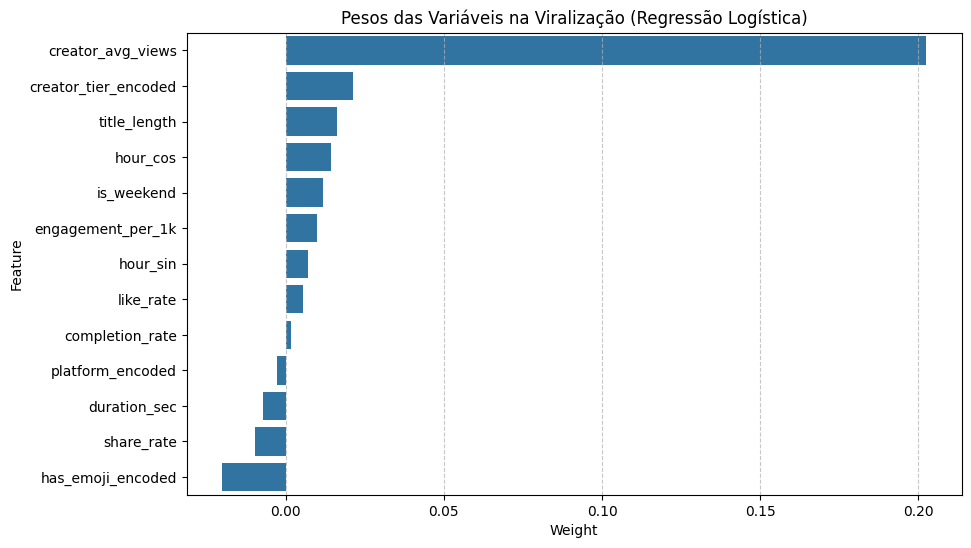

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = pd.DataFrame({
    'Feature': features,
    'Weight': model_lr.coef_[0]
}).sort_values(by='Weight', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Weight', y='Feature', data=importances)
plt.title('Pesos das Variáveis na Viralização (Regressão Logística)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

O gráfico dos coeficientes revela que o principal preditor de viralização não é o conteúdo em si (como *like_rate* ou *completion_rate*), mas sim a autoridade prévia do canal (creator_avg_views). Variáveis de engajamento imediato apresentam pesos marginais, o que explica a dificuldade dos modelos complexos: não há sinal forte o suficiente nas métricas de performance para isolar o fenômeno de viralização. Curiosamente, a presença de emojis e altas taxas de compartilhamento (*share_rate*) apresentaram correlação negativa ou nula, sugerindo que o algoritmo de distribuição pode priorizar a retenção passiva ou a autoridade do perfil sobre interações explícitas.

**Veredito**

Os resultados obtidos, com um ROC AUC estabilizado na casa dos 0.55, indicam que a viralização em redes sociais como TikTok e YouTube Shorts é um **fenômeno de complexidade estocástica superior**.

Concluímos que:

1. **Dados insuficientes**: As métricas quantitativas disponíveis capturam apenas a superfície do engajamento. Variáveis qualitativas crucias, como timing do algoritmo de recomendação, não estão presentes no dataset.

2. **Imprevisibilidade**: O sucesso de um conteúdo parece ser governado por leis de potência e eventos de cauda longa que desafiam modelos tradicionais. Mesmo com o refinamento dos algoritmos, o problema permance sem solução satisfatória, sugerindo que, na ausência de dados de visão computacional ou análise semântica profunda, a viralização continuará sendo um evento onde a sorte e o contexto externo pesam tanto quanto a técnica de postagem.